# WASP-76b TESS Exploration With mlexo

This notebook keeps the original `lightkurve` exploration flow from `kelt20b-tess.ipynb`, but replaces the old PyMC / exoplanet and JAX modeling path with your local `mlexo` checkout.

Notes:
- The TESS download, normalization, and detrending steps remain CPU / `lightkurve` code.
- The transit forward model comes from the local `mlexo` checkout.
- The fit here is deterministic (`scipy.optimize.minimize`) because the local `mlexo` package currently exposes forward-model pieces, not a sampler.
- The bootstrap cell below imports the current `mlexo` package layout directly from the sibling checkout.
        


In [1]:
import warnings

import lightkurve as lk
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning, module="pytensor")

TARGET = "WASP-76"
MISSION = "TESS"
AUTHOR = "SPOC"
EXPTIME_S = 120

PERIOD_D = 1.809886
T0_BTJD = 2000.052898
TRANSIT_DURATION_D = 0.153917
PLOT_WINDOW_D = 0.15
MODEL_WINDOW_D = PLOT_WINDOW_D
RADIUS_RATIO_GUESS = 0.1063
B_GUESS = 0.14
LC_ORDER = 20
EXPOSURE_TIME_D = EXPTIME_S / 86400.0

search = lk.search_lightcurve(TARGET, mission=MISSION, author=AUTHOR, exptime=EXPTIME_S)
display(search)

lc_collection = search.download_all()
print(f"Downloaded {len(lc_collection)} light curves")
        


/opt/homebrew/Caskroom/miniconda/base/envs/exometal/lib/python3.10/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 30,2020,SPOC,120,293435336,0.0
1,TESS Sector 42,2021,SPOC,120,293435336,0.0
2,TESS Sector 43,2021,SPOC,120,293435336,0.0
3,TESS Sector 97,2025,SPOC,120,293435336,0.0


Downloaded 4 light curves


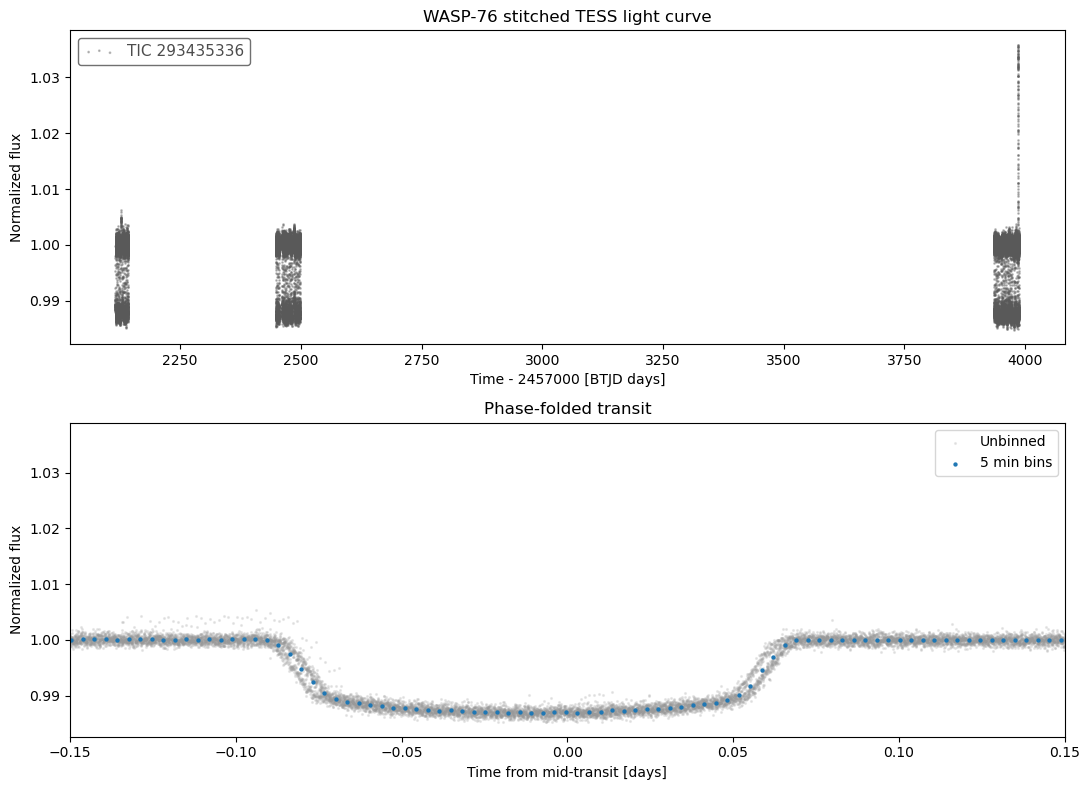

In [2]:
stitched_lc = lc_collection.stitch().remove_nans().normalize()
transit_mask = stitched_lc.create_transit_mask(
    period=PERIOD_D,
    transit_time=T0_BTJD,
    duration=TRANSIT_DURATION_D,
)
flat_lc = stitched_lc.flatten(window_length=901, mask=transit_mask)
folded_lc = flat_lc.fold(period=PERIOD_D, epoch_time=T0_BTJD)
binned_folded_lc = folded_lc.bin(time_bin_size=5.0 / (24.0 * 60.0))

fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=False)

stitched_lc.scatter(ax=axes[0], color="0.35", alpha=0.35, s=4)
axes[0].set_title("WASP-76 stitched TESS light curve")
axes[0].set_ylabel("Normalized flux")

folded_lc.scatter(ax=axes[1], color="0.6", alpha=0.18, s=6, label="Unbinned")
binned_folded_lc.scatter(ax=axes[1], color="tab:blue", s=18, label="5 min bins")
axes[1].set_xlim(-PLOT_WINDOW_D, PLOT_WINDOW_D)
axes[1].set_title("Phase-folded transit")
axes[1].set_xlabel("Time from mid-transit [days]")
axes[1].set_ylabel("Normalized flux")
axes[1].legend()

plt.tight_layout()
        


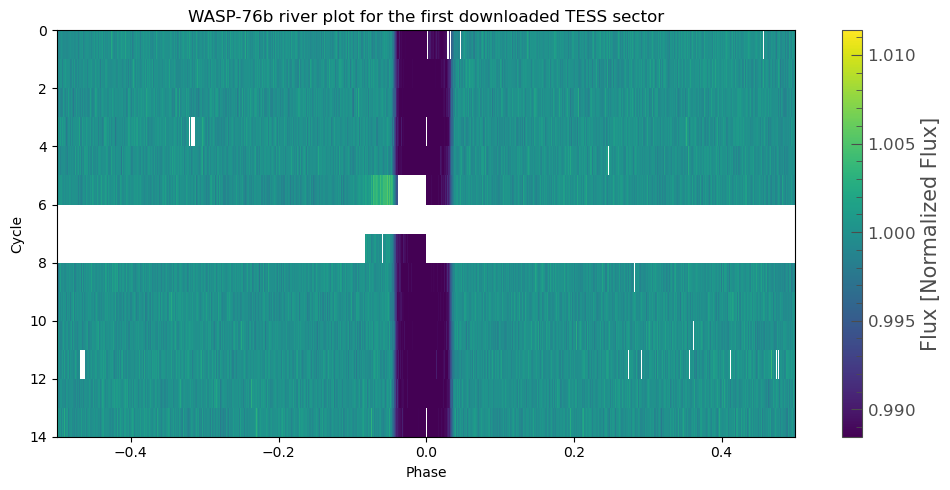

In [3]:
sector_lc = lc_collection[0].remove_nans().normalize()
sector_transit_mask = sector_lc.create_transit_mask(
    period=PERIOD_D,
    transit_time=T0_BTJD,
    duration=TRANSIT_DURATION_D,
)
sector_flat_lc = sector_lc.flatten(window_length=901, mask=sector_transit_mask)
sector_folded_lc = sector_flat_lc.fold(period=PERIOD_D, epoch_time=T0_BTJD)

fig, ax = plt.subplots(figsize=(10, 5))
sector_folded_lc.plot_river(ax=ax)
ax.set_aspect("auto")
ax.set_title("WASP-76b river plot for the first downloaded TESS sector")
plt.tight_layout()
        


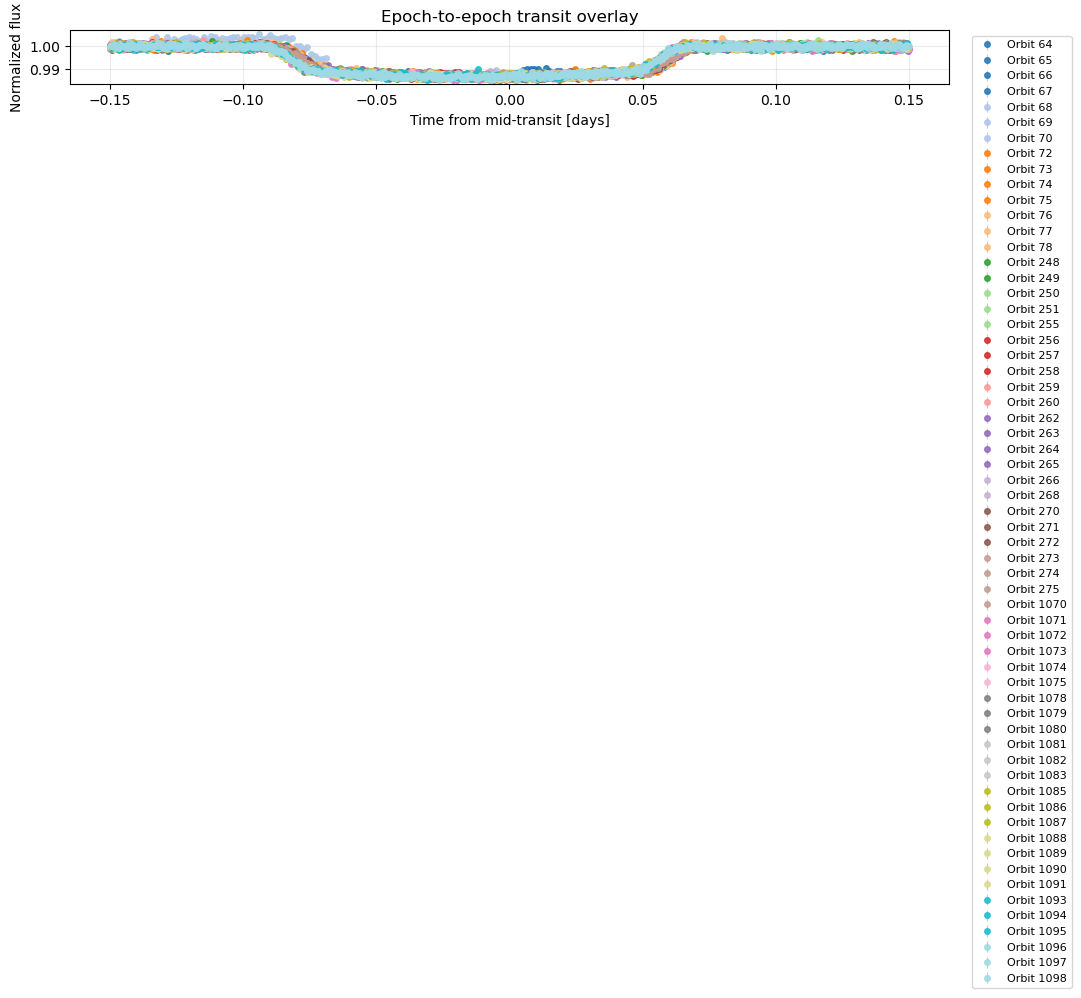

In [4]:
time_btjd = flat_lc.time.value
phase_days = ((time_btjd - T0_BTJD + 0.5 * PERIOD_D) % PERIOD_D) - 0.5 * PERIOD_D
epoch_number = np.round((time_btjd - T0_BTJD) / PERIOD_D).astype(int)

fig, ax = plt.subplots(figsize=(11, 6))
unique_epochs = np.unique(epoch_number)
colors = plt.cm.tab20(np.linspace(0, 1, len(unique_epochs)))

for color, current_epoch in zip(colors, unique_epochs):
    mask = (epoch_number == current_epoch) & (np.abs(phase_days) < PLOT_WINDOW_D)
    if not np.any(mask):
        continue
    ax.errorbar(
        phase_days[mask],
        flat_lc.flux.value[mask],
        yerr=flat_lc.flux_err.value[mask],
        fmt="o",
        ms=4,
        color=color,
        ecolor="0.75",
        elinewidth=0.8,
        capsize=0,
        alpha=0.85,
        label=f"Orbit {current_epoch}",
    )

ax.set_title("Epoch-to-epoch transit overlay")
ax.set_xlabel("Time from mid-transit [days]")
ax.set_ylabel("Normalized flux")
ax.grid(alpha=0.25)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, ncol=1)
plt.tight_layout()
        


## Joint Multi-Sector Transit + Per-Sector GP Model With Local mlexo

The next cells keep the shared Keplerian transit model from your local `mlexo` checkout, but add an independent exact GP to each TESS sector. The GP is block-diagonal across sectors, so there is no covariance across long inter-sector gaps.
        


In [5]:
def build_joint_tess_dataset(lc_collection, period_d, t0_btjd, transit_duration_d, model_window_d):
    sector_labels = []
    x_parts = []
    y_parts = []
    yerr_parts = []
    sector_idx_parts = []

    for sector_number, raw_lc in enumerate(lc_collection, start=1):
        sector_label = raw_lc.meta.get("MISSION", f"sector_{sector_number}")
        sector_lc = raw_lc.remove_nans().normalize()
        transit_mask = sector_lc.create_transit_mask(
            period=period_d,
            transit_time=t0_btjd,
            duration=transit_duration_d,
        )
        _, oot_outlier_mask = sector_lc[~transit_mask].remove_outliers(sigma=5.0, return_mask=True)
        keep_mask = np.ones(len(sector_lc), dtype=bool)
        oot_rows = np.flatnonzero(~transit_mask)
        keep_mask[oot_rows[oot_outlier_mask]] = False
        sector_lc = sector_lc[keep_mask]
        transit_mask = sector_lc.create_transit_mask(
            period=period_d,
            transit_time=t0_btjd,
            duration=transit_duration_d,
        )
        sector_flat = sector_lc.flatten(window_length=901, mask=transit_mask)

        sector_phase = ((sector_flat.time.value - t0_btjd + 0.5 * period_d) % period_d) - 0.5 * period_d
        window_mask = np.abs(sector_phase) < model_window_d
        if not np.any(window_mask):
            continue

        flux = np.asarray(sector_flat.flux.value, dtype=np.float64)
        flux_err = np.asarray(sector_flat.flux_err.value, dtype=np.float64)

        finite_flux = flux[np.isfinite(flux)]
        flux_fill = float(np.median(finite_flux)) if finite_flux.size else 1.0
        flux = np.where(np.isfinite(flux), flux, flux_fill)

        finite_err = flux_err[np.isfinite(flux_err) & (flux_err > 0)]
        err_fill = float(np.median(finite_err)) if finite_err.size else 5.0e-4
        flux_err = np.where(np.isfinite(flux_err) & (flux_err > 0), flux_err, err_fill)

        x_parts.append(np.ascontiguousarray(sector_flat.time.value[window_mask], dtype=np.float64))
        y_parts.append(np.ascontiguousarray(flux[window_mask] - 1.0, dtype=np.float64))
        yerr_parts.append(np.ascontiguousarray(flux_err[window_mask], dtype=np.float64))
        sector_idx_parts.append(np.full(np.count_nonzero(window_mask), len(sector_labels), dtype=np.int32))
        sector_labels.append(sector_label)

    if not x_parts:
        raise RuntimeError("No TESS cadences survived the preprocessing window.")

    x = np.concatenate(x_parts)
    y = np.concatenate(y_parts)
    yerr = np.concatenate(yerr_parts)
    sector_idx = np.concatenate(sector_idx_parts)

    sort_idx = np.argsort(x)
    x = x[sort_idx]
    y = y[sort_idx]
    yerr = yerr[sort_idx]
    sector_idx = sector_idx[sort_idx]

    n_sectors = len(sector_labels)
    sector_counts = np.bincount(sector_idx, minlength=n_sectors)
    sector_rows = [np.flatnonzero(sector_idx == i) for i in range(n_sectors)]

    return {
        "time": x,
        "flux": y,
        "flux_err": yerr,
        "sector_idx": sector_idx,
        "sector_labels": sector_labels,
        "sector_counts": sector_counts,
        "sector_rows": sector_rows,
        "n_sectors": n_sectors,
    }


dataset = build_joint_tess_dataset(
    lc_collection=lc_collection,
    period_d=PERIOD_D,
    t0_btjd=T0_BTJD,
    transit_duration_d=TRANSIT_DURATION_D,
    model_window_d=MODEL_WINDOW_D,
)

print(f"Prepared {dataset['time'].size} cadences across {dataset['n_sectors']} sectors")
for label, count in zip(dataset["sector_labels"], dataset["sector_counts"]):
    print(f"  {label}: {int(count)} cadences in the transit window")
        


Prepared 12128 cadences across 4 sectors
  TESS: 2701 cadences in the transit window
  TESS: 2124 cadences in the transit window
  TESS: 2505 cadences in the transit window
  TESS: 4798 cadences in the transit window


In [6]:
import hashlib
import json
import os
import sys
from multiprocessing import get_context
from pathlib import Path

import emcee
from scipy.optimize import minimize

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "environment-exometal.yml").exists() and (PROJECT_ROOT.parent / "environment-exometal.yml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

MLEXO_ROOT = PROJECT_ROOT.parent / "mlexo"
if not MLEXO_ROOT.exists():
    raise FileNotFoundError(f"Local mlexo checkout not found: {MLEXO_ROOT}")

if str(MLEXO_ROOT.parent) not in sys.path:
    sys.path.insert(0, str(MLEXO_ROOT.parent))

import mlx.core as mx
import mlexo
import mlexo.light_curves.transforms as lc_transforms
from mlexo import constants as mlexo_constants
from mlexo.light_curves.limb_dark import light_curve as limb_dark_light_curve
from mlexo.orbits.keplerian import Body, Central, OrbitalBody

RHO_SUN_UNIT = 3.0 / (4.0 * np.pi)
RHO_STAR_SOLAR_GUESS = 0.3938
RHO_STAR_SOLAR_SIGMA = 0.10
GP_RHO_GUESS_D = 0.05
GP_RHO_MIN_D = max(5.0 * EXPOSURE_TIME_D, 0.01)
GP_RHO_MAX_D = 0.30
GP_EPS = 1.0e-9
GP_MX_DTYPE = mx.float32
EMCEE_NWALKERS_MIN = 48
EMCEE_BURNIN_STEPS = 150
EMCEE_PRODUCTION_STEPS = 300
EMCEE_THIN = 5
EMCEE_INIT_SCALE = 1.0e-3
EMCEE_USE_POOL = False
EMCEE_N_PROCESSES = max(1, min(4, (os.cpu_count() or 1) - 1))
EMCEE_START_METHOD = "fork"
RUN_CACHE_VERSION = "mlx_cpu_gp_emcee_cache_v1"
FORCE_RERUN = False
RUN_CACHE_DIR = PROJECT_ROOT / "notebooks" / ".cache" / "wasp76b-tess-mlexo"
print("Loaded local mlexo from", MLEXO_ROOT)


Loaded local mlexo from /Volumes/drive-2tb/code/mlexo


In [7]:
def kipping_q_to_u(q1, q2):
    sqrt_q1 = np.sqrt(np.clip(q1, 0.0, 1.0))
    u1 = 2.0 * sqrt_q1 * q2
    u2 = sqrt_q1 * (1.0 - 2.0 * q2)
    return np.asarray([u1, u2], dtype=np.float64)


def rho_star_solar_to_a_over_rstar(period, rho_star_solar):
    period = np.asarray(period, dtype=np.float64)
    rho_star_solar = np.asarray(rho_star_solar, dtype=np.float64)
    rho_star_unit = rho_star_solar * RHO_SUN_UNIT
    return ((mlexo_constants.G * period**2 * rho_star_unit) / (3.0 * np.pi)) ** (1.0 / 3.0)


def circular_transit_duration(period, a_over_rstar, b, r):
    chord = np.sqrt(np.clip((1.0 + r) ** 2 - b**2, 0.0, None))
    sin_i = np.sqrt(np.clip(1.0 - (b / a_over_rstar) ** 2, 1.0e-12, 1.0))
    arg = np.clip(chord / (a_over_rstar * sin_i), 0.0, 1.0)
    return (period / np.pi) * np.arcsin(arg)


def matern32_kernel_mx(time_mx, gp_sigma_mx, gp_rho_mx):
    dt = mx.abs(time_mx[:, None] - time_mx[None, :])
    sqrt3 = mx.sqrt(mx.array(3.0, dtype=time_mx.dtype))
    scaled = sqrt3 * dt / gp_rho_mx
    return gp_sigma_mx**2 * (1.0 + scaled) * mx.exp(-scaled)


def gp_cholesky_solve(cov, rhs):
    chol = mx.linalg.cholesky(cov, stream=mx.cpu)
    y = mx.linalg.solve_triangular(chol, rhs, upper=False, stream=mx.cpu)
    alpha = mx.linalg.solve_triangular(mx.transpose(chol), y, upper=True, stream=mx.cpu)
    return chol, alpha


def sector_gp_marginal_nll(time, resid, flux_err, gp_sigma, gp_rho, jitter, eps=GP_EPS):
    time_mx = mx.array(time, dtype=GP_MX_DTYPE)
    resid_mx = mx.array(resid, dtype=GP_MX_DTYPE)[:, None]
    flux_err_mx = mx.array(flux_err, dtype=GP_MX_DTYPE)
    gp_sigma_mx = mx.array(gp_sigma, dtype=GP_MX_DTYPE)
    gp_rho_mx = mx.array(gp_rho, dtype=GP_MX_DTYPE)
    jitter_mx = mx.array(jitter, dtype=GP_MX_DTYPE)

    k_signal = matern32_kernel_mx(time_mx, gp_sigma_mx, gp_rho_mx)
    diag = flux_err_mx**2 + jitter_mx**2 + mx.array(eps, dtype=GP_MX_DTYPE)
    cov = mx.array(k_signal + mx.diag(diag), dtype=GP_MX_DTYPE)

    try:
        chol, alpha = gp_cholesky_solve(cov, resid_mx)
    except Exception:
        return np.inf

    quad = mx.sum(resid_mx * alpha)
    logdet = 2.0 * mx.sum(mx.log(mx.diag(chol)))
    n_data = float(time.shape[0])
    nll = 0.5 * (quad + logdet + n_data * np.log(2.0 * np.pi))
    return float(np.asarray(nll))


def sector_gp_posterior_mean(time, resid, flux_err, gp_sigma, gp_rho, jitter, eps=GP_EPS):
    time_mx = mx.array(time, dtype=GP_MX_DTYPE)
    resid_mx = mx.array(resid, dtype=GP_MX_DTYPE)[:, None]
    flux_err_mx = mx.array(flux_err, dtype=GP_MX_DTYPE)
    gp_sigma_mx = mx.array(gp_sigma, dtype=GP_MX_DTYPE)
    gp_rho_mx = mx.array(gp_rho, dtype=GP_MX_DTYPE)
    jitter_mx = mx.array(jitter, dtype=GP_MX_DTYPE)

    k_signal = matern32_kernel_mx(time_mx, gp_sigma_mx, gp_rho_mx)
    diag = flux_err_mx**2 + jitter_mx**2 + mx.array(eps, dtype=GP_MX_DTYPE)
    cov = mx.array(k_signal + mx.diag(diag), dtype=GP_MX_DTYPE)
    _, alpha = gp_cholesky_solve(cov, resid_mx)
    gp_mean = k_signal @ alpha
    return np.asarray(gp_mean, dtype=np.float64).reshape(-1)


def unpack_params(theta, n_sectors):
    theta = np.asarray(theta, dtype=np.float64)
    period = np.exp(theta[0])
    t0 = theta[1]
    rho_star_solar = np.exp(theta[2])
    r = np.exp(theta[3])
    b_scaled = theta[4]
    q1 = theta[5]
    q2 = theta[6]

    mean_flux = theta[7 : 7 + n_sectors]
    log_jitter = theta[7 + n_sectors : 7 + 2 * n_sectors]
    log_gp_sigma = theta[7 + 2 * n_sectors : 7 + 3 * n_sectors]
    log_gp_rho = theta[7 + 3 * n_sectors : 7 + 4 * n_sectors]

    jitter = np.exp(log_jitter)
    gp_sigma = np.exp(log_gp_sigma)
    gp_rho = np.exp(log_gp_rho)

    b = b_scaled * (1.0 + r)
    a_over_rstar = rho_star_solar_to_a_over_rstar(period, rho_star_solar)
    cos_i = np.clip(b / a_over_rstar, -1.0, 1.0)
    duration = circular_transit_duration(period, a_over_rstar, b, r)

    return {
        "period": period,
        "t0": t0,
        "rho_star_solar": rho_star_solar,
        "rho_star_unit": rho_star_solar * RHO_SUN_UNIT,
        "a_over_rstar": a_over_rstar,
        "duration": duration,
        "inclination_deg": np.degrees(np.arccos(cos_i)),
        "r": r,
        "b": b,
        "q1": q1,
        "q2": q2,
        "u": kipping_q_to_u(q1, q2),
        "mean_flux": mean_flux,
        "log_jitter": log_jitter,
        "jitter": jitter,
        "log_gp_sigma": log_gp_sigma,
        "gp_sigma": gp_sigma,
        "log_gp_rho": log_gp_rho,
        "gp_rho": gp_rho,
    }


def mlexo_transit_flux(time, period, t0, a_over_rstar, b, r, u, exposure_time_d=EXPOSURE_TIME_D, lc_order=LC_ORDER):
    central = Central.from_orbital_properties(
        period=period,
        semimajor=a_over_rstar,
        radius=1.0,
    )
    body = Body(
        period=period,
        time_transit=t0,
        impact_param=b,
        radius=r,
    )
    orbit = OrbitalBody(central, body)
    flux_func = limb_dark_light_curve(orbit, u, order=lc_order)
    if exposure_time_d and exposure_time_d > 0:
        flux_func = lc_transforms.integrate(
            flux_func,
            exposure_time=exposure_time_d,
            order=1,
            num_samples=7,
        )
    flux = flux_func(mx.array(time))
    return np.asarray(flux, dtype=np.float64)


def build_gp_trend(time, flux, flux_err, sector_rows, transit_model, pars):
    gp_trend = np.zeros_like(flux)
    for sector_id, rows in enumerate(sector_rows):
        baseline = transit_model[rows] + pars["mean_flux"][sector_id]
        resid = flux[rows] - baseline
        gp_trend[rows] = sector_gp_posterior_mean(
            time=time[rows],
            resid=resid,
            flux_err=flux_err[rows],
            gp_sigma=pars["gp_sigma"][sector_id],
            gp_rho=pars["gp_rho"][sector_id],
            jitter=pars["jitter"][sector_id],
        )
    return gp_trend


def negative_log_posterior(theta, time, flux, flux_err, sector_rows, n_sectors):
    pars = unpack_params(theta, n_sectors)
    transit_model = mlexo_transit_flux(
        time=time,
        period=pars["period"],
        t0=pars["t0"],
        a_over_rstar=pars["a_over_rstar"],
        b=pars["b"],
        r=pars["r"],
        u=pars["u"],
    )

    nll = 0.0
    for sector_id, rows in enumerate(sector_rows):
        baseline = transit_model[rows] + pars["mean_flux"][sector_id]
        resid = flux[rows] - baseline
        nll += sector_gp_marginal_nll(
            time=time[rows],
            resid=resid,
            flux_err=flux_err[rows],
            gp_sigma=pars["gp_sigma"][sector_id],
            gp_rho=pars["gp_rho"][sector_id],
            jitter=pars["jitter"][sector_id],
        )

    flux_err_ref = max(float(np.median(flux_err)), 1.0e-6)
    prior = 0.0
    prior += 0.5 * ((pars["period"] - PERIOD_D) / 2.0e-4) ** 2
    prior += 0.5 * ((pars["t0"] - T0_BTJD) / 3.0e-3) ** 2
    prior += 0.5 * ((pars["rho_star_solar"] - RHO_STAR_SOLAR_GUESS) / RHO_STAR_SOLAR_SIGMA) ** 2
    prior += 0.5 * ((pars["r"] - RADIUS_RATIO_GUESS) / 0.03) ** 2
    prior += 0.5 * ((pars["b"] - B_GUESS) / 0.25) ** 2
    prior += 0.5 * np.sum((pars["mean_flux"] / 5.0e-4) ** 2)
    prior += 0.5 * np.sum(((pars["log_jitter"] - np.log(flux_err_ref)) / 2.0) ** 2)
    prior += 0.5 * np.sum(((pars["log_gp_sigma"] - np.log(flux_err_ref)) / 2.0) ** 2)
    prior += 0.5 * np.sum(((pars["log_gp_rho"] - np.log(GP_RHO_GUESS_D)) / 1.0) ** 2)

    return float(nll + prior)


def summarize_interval(samples):
    samples = np.asarray(samples, dtype=np.float64).reshape(-1)
    q16, q50, q84 = np.percentile(samples, [16.0, 50.0, 84.0])
    return {
        "lower": float(q16),
        "median": float(q50),
        "upper": float(q84),
        "plus": float(q84 - q50),
        "minus": float(q50 - q16),
    }


def build_bounds(n_sectors):
    bounds = [
        (np.log(PERIOD_D - 0.01), np.log(PERIOD_D + 0.01)),
        (T0_BTJD - 0.05, T0_BTJD + 0.05),
        (np.log(0.05), np.log(3.0)),
        (np.log(0.01), np.log(0.25)),
        (0.0, 1.0),
        (1.0e-6, 1.0),
        (1.0e-6, 1.0),
    ]
    bounds.extend([(-5.0e-3, 5.0e-3)] * n_sectors)
    bounds.extend([(np.log(1.0e-7), np.log(5.0e-3))] * n_sectors)
    bounds.extend([(np.log(1.0e-7), np.log(5.0e-3))] * n_sectors)
    bounds.extend([(np.log(GP_RHO_MIN_D), np.log(GP_RHO_MAX_D))] * n_sectors)
    return np.asarray(bounds, dtype=np.float64)


def in_bounds(theta, bounds):
    theta = np.asarray(theta, dtype=np.float64)
    return np.all(theta >= bounds[:, 0]) and np.all(theta <= bounds[:, 1])


def log_probability(theta, time, flux, flux_err, sector_rows, n_sectors, bounds):
    theta = np.asarray(theta, dtype=np.float64)
    if not np.all(np.isfinite(theta)) or not in_bounds(theta, bounds):
        return -np.inf

    try:
        nlp = negative_log_posterior(theta, time, flux, flux_err, sector_rows, n_sectors)
    except Exception:
        return -np.inf

    if not np.isfinite(nlp):
        return -np.inf
    return -float(nlp)


def initialize_walkers(theta_map, bounds, n_walkers, seed=123, init_scale=EMCEE_INIT_SCALE):
    theta_map = np.asarray(theta_map, dtype=np.float64)
    bounds = np.asarray(bounds, dtype=np.float64)
    widths = bounds[:, 1] - bounds[:, 0]
    eps = np.maximum(1.0e-8, 1.0e-6 * widths)
    lower = bounds[:, 0] + eps
    upper = bounds[:, 1] - eps

    rng = np.random.default_rng(seed)
    walkers = theta_map + init_scale * widths * rng.standard_normal((n_walkers, theta_map.size))
    walkers = np.clip(walkers, lower, upper)

    for idx in range(n_walkers):
        if np.allclose(walkers[idx], theta_map):
            walkers[idx] = np.clip(theta_map + eps * rng.standard_normal(theta_map.size), lower, upper)
    return walkers


def run_emcee_sampler(initial_walkers, time, flux, flux_err, sector_rows, n_sectors, bounds):
    ndim = initial_walkers.shape[1]
    n_walkers = initial_walkers.shape[0]
    args = (time, flux, flux_err, sector_rows, n_sectors, bounds)
    worker_count = min(int(EMCEE_N_PROCESSES), int(n_walkers))

    if EMCEE_USE_POOL and worker_count > 1:
        try:
            ctx = get_context(EMCEE_START_METHOD)
            with ctx.Pool(processes=worker_count) as pool:
                print(f"Running emcee with {worker_count} worker processes ({EMCEE_START_METHOD})")
                sampler = emcee.EnsembleSampler(
                    n_walkers,
                    ndim,
                    log_probability,
                    args=args,
                    pool=pool,
                )
                state = sampler.run_mcmc(initial_walkers, EMCEE_BURNIN_STEPS, progress=True)
                sampler.reset()
                sampler.run_mcmc(state, EMCEE_PRODUCTION_STEPS, progress=True)
                return sampler, True, worker_count
        except Exception as exc:
            print(f"Parallel emcee failed ({exc}). Falling back to serial.")

    print("Running emcee serially")
    sampler = emcee.EnsembleSampler(
        n_walkers,
        ndim,
        log_probability,
        args=args,
    )
    state = sampler.run_mcmc(initial_walkers, EMCEE_BURNIN_STEPS, progress=True)
    sampler.reset()
    sampler.run_mcmc(state, EMCEE_PRODUCTION_STEPS, progress=True)
    return sampler, False, 1


def summarize_posterior_samples(theta_samples, n_sectors):
    theta_samples = np.asarray(theta_samples, dtype=np.float64)
    if theta_samples.size == 0:
        return None

    keys = ["r", "b", "rho_star_solar", "a_over_rstar", "inclination_deg", "duration", "q1", "q2", "u1", "u2"]
    derived = {key: [] for key in keys}
    depth_percent = []

    for theta in theta_samples:
        pars = unpack_params(theta, n_sectors)
        derived["r"].append(pars["r"])
        derived["b"].append(pars["b"])
        derived["rho_star_solar"].append(pars["rho_star_solar"])
        derived["a_over_rstar"].append(pars["a_over_rstar"])
        derived["inclination_deg"].append(pars["inclination_deg"])
        derived["duration"].append(pars["duration"])
        derived["q1"].append(pars["q1"])
        derived["q2"].append(pars["q2"])
        derived["u1"].append(pars["u"][0])
        derived["u2"].append(pars["u"][1])
        depth_percent.append(100.0 * pars["r"] ** 2)

    summary = {key: summarize_interval(values) for key, values in derived.items()}
    summary["transit_depth_percent"] = summarize_interval(depth_percent)
    return summary


def hash_array(arr):
    arr = np.ascontiguousarray(np.asarray(arr))
    digest = hashlib.sha256()
    digest.update(str(arr.dtype).encode("utf-8"))
    digest.update(json.dumps(arr.shape).encode("utf-8"))
    digest.update(arr.tobytes())
    return digest.hexdigest()


def build_run_config(dataset):
    return {
        "cache_version": RUN_CACHE_VERSION,
        "notebook": "wasp76b-tess-mlexo.ipynb",
        "mlexo_root": str(MLEXO_ROOT),
        "dataset": {
            "n_sectors": int(dataset["n_sectors"]),
            "sector_labels": [str(label) for label in dataset["sector_labels"]],
            "sector_counts": [int(count) for count in dataset["sector_counts"]],
            "hashes": {
                "time": hash_array(dataset["time"]),
                "flux": hash_array(dataset["flux"]),
                "flux_err": hash_array(dataset["flux_err"]),
                "sector_idx": hash_array(dataset["sector_idx"]),
            },
        },
        "model": {
            "period_d": float(PERIOD_D),
            "t0_btjd": float(T0_BTJD),
            "transit_duration_d": float(TRANSIT_DURATION_D),
            "plot_window_d": float(PLOT_WINDOW_D),
            "model_window_d": float(MODEL_WINDOW_D),
            "exposure_time_d": float(EXPOSURE_TIME_D),
            "lc_order": int(LC_ORDER),
            "radius_ratio_guess": float(RADIUS_RATIO_GUESS),
            "impact_guess": float(B_GUESS),
            "rho_star_solar_guess": float(RHO_STAR_SOLAR_GUESS),
            "rho_star_solar_sigma": float(RHO_STAR_SOLAR_SIGMA),
            "gp_rho_guess_d": float(GP_RHO_GUESS_D),
            "gp_rho_min_d": float(GP_RHO_MIN_D),
            "gp_rho_max_d": float(GP_RHO_MAX_D),
            "gp_eps": float(GP_EPS),
        },
        "sampler": {
            "emcee_nwalkers_min": int(EMCEE_NWALKERS_MIN),
            "emcee_burnin_steps": int(EMCEE_BURNIN_STEPS),
            "emcee_production_steps": int(EMCEE_PRODUCTION_STEPS),
            "emcee_thin": int(EMCEE_THIN),
            "emcee_init_scale": float(EMCEE_INIT_SCALE),
        },
    }


def resolve_cache_paths(run_config):
    payload = json.dumps(run_config, sort_keys=True, separators=(",", ":")).encode("utf-8")
    run_id = hashlib.sha256(payload).hexdigest()[:16]
    run_dir = RUN_CACHE_DIR / run_id
    return {
        "run_id": run_id,
        "dir": run_dir,
        "json": run_dir / "run.json",
        "npz": run_dir / "outputs.npz",
    }


def save_run_cache(best_fit, run_config, cache_paths):
    cache_paths["dir"].mkdir(parents=True, exist_ok=True)

    scalar_keys = [
        "period",
        "t0",
        "rho_star_solar",
        "rho_star_unit",
        "a_over_rstar",
        "duration",
        "inclination_deg",
        "r",
        "b",
        "q1",
        "q2",
        "emcee_acceptance_fraction",
    ]
    scalars = {key: float(best_fit[key]) for key in scalar_keys if key in best_fit}

    metadata = {
        "run_id": cache_paths["run_id"],
        "run_config": run_config,
        "summary_stats": best_fit.get("summary_stats"),
        "scalars": scalars,
        "execution": {
            "emcee_parallel": bool(best_fit.get("emcee_parallel", False)),
            "emcee_worker_count": int(best_fit.get("emcee_worker_count", 1)),
        },
        "posterior_samples": int(best_fit["posterior_theta"].shape[0]),
        "cache_json": str(cache_paths["json"]),
        "cache_npz": str(cache_paths["npz"]),
    }
    cache_paths["json"].write_text(json.dumps(metadata, indent=2, sort_keys=True))

    array_keys = [
        "u",
        "mean_flux",
        "log_jitter",
        "jitter",
        "log_gp_sigma",
        "gp_sigma",
        "log_gp_rho",
        "gp_rho",
        "transit_model",
        "gp_trend",
        "mean_model",
        "detrended_flux",
        "residual_flux",
        "phase_days",
        "phase_grid",
        "phase_model_grid",
        "posterior_theta",
        "posterior_log_prob",
    ]
    arrays = {key: np.asarray(best_fit[key]) for key in array_keys if key in best_fit}
    np.savez_compressed(cache_paths["npz"], **arrays)


def load_run_cache(cache_paths):
    metadata = json.loads(cache_paths["json"].read_text())
    best_fit = {}
    with np.load(cache_paths["npz"], allow_pickle=False) as arrays:
        for key in arrays.files:
            best_fit[key] = np.array(arrays[key])

    for key, value in metadata.get("scalars", {}).items():
        best_fit[key] = value

    execution = metadata.get("execution", {})
    best_fit["emcee_parallel"] = bool(execution.get("emcee_parallel", False))
    best_fit["emcee_worker_count"] = int(execution.get("emcee_worker_count", 1))
    best_fit["summary_stats"] = metadata.get("summary_stats")
    best_fit["cache_run_id"] = metadata["run_id"]
    best_fit["cache_json"] = metadata.get("cache_json", str(cache_paths["json"]))
    best_fit["cache_npz"] = metadata.get("cache_npz", str(cache_paths["npz"]))
    return best_fit


In [8]:
run_config = build_run_config(dataset)
cache_paths = resolve_cache_paths(run_config)
loaded_from_cache = False

if not FORCE_RERUN and cache_paths["json"].exists() and cache_paths["npz"].exists():
    try:
        best_fit = load_run_cache(cache_paths)
        loaded_from_cache = True
        print(f"Loaded cached run {cache_paths['run_id']} from {cache_paths['dir']}")
    except Exception as exc:
        print(f"Cache load failed for run {cache_paths['run_id']}: {exc}")
        print("Recomputing fit from scratch.")

if not loaded_from_cache:
    gp_sigma_guess = max(float(np.median(dataset["flux_err"])), 1.0e-6)
    bounds = build_bounds(dataset["n_sectors"])

    theta0 = np.concatenate(
        [
            np.array([
                np.log(PERIOD_D),
                T0_BTJD,
                np.log(RHO_STAR_SOLAR_GUESS),
                np.log(RADIUS_RATIO_GUESS),
                B_GUESS / (1.0 + RADIUS_RATIO_GUESS),
                0.25,
                0.25,
            ], dtype=np.float64),
            np.zeros(dataset["n_sectors"], dtype=np.float64),
            np.full(dataset["n_sectors"], np.log(gp_sigma_guess), dtype=np.float64),
            np.full(dataset["n_sectors"], np.log(gp_sigma_guess), dtype=np.float64),
            np.full(dataset["n_sectors"], np.log(GP_RHO_GUESS_D), dtype=np.float64),
        ]
    )

    result = minimize(
        negative_log_posterior,
        theta0,
        args=(
            dataset["time"],
            dataset["flux"],
            dataset["flux_err"],
            dataset["sector_rows"],
            dataset["n_sectors"],
        ),
        method="L-BFGS-B",
        bounds=bounds,
        options={"maxiter": 1000, "maxfun": 20000},
    )

    if not result.success:
        print("Optimizer warning:", result.message)

    ndim = result.x.size
    n_walkers = max(EMCEE_NWALKERS_MIN, 2 * ndim)
    initial_walkers = initialize_walkers(result.x, bounds, n_walkers, seed=123, init_scale=EMCEE_INIT_SCALE)

    sampler, used_parallel_emcee, emcee_worker_count = run_emcee_sampler(
        initial_walkers=initial_walkers,
        time=dataset["time"],
        flux=dataset["flux"],
        flux_err=dataset["flux_err"],
        sector_rows=dataset["sector_rows"],
        n_sectors=dataset["n_sectors"],
        bounds=bounds,
    )
    posterior_theta = sampler.get_chain(flat=True, thin=EMCEE_THIN)
    posterior_log_prob = sampler.get_log_prob(flat=True, thin=EMCEE_THIN)

    finite_mask = np.isfinite(posterior_log_prob)
    posterior_theta = posterior_theta[finite_mask]
    posterior_log_prob = posterior_log_prob[finite_mask]
    if posterior_theta.size == 0:
        raise RuntimeError("emcee produced no finite posterior samples.")

    best_idx = int(np.argmax(posterior_log_prob))
    theta_best = posterior_theta[best_idx]

    best_fit = unpack_params(theta_best, dataset["n_sectors"])
    best_fit["transit_model"] = mlexo_transit_flux(
        time=dataset["time"],
        period=best_fit["period"],
        t0=best_fit["t0"],
        a_over_rstar=best_fit["a_over_rstar"],
        b=best_fit["b"],
        r=best_fit["r"],
        u=best_fit["u"],
    )
    best_fit["gp_trend"] = build_gp_trend(
        time=dataset["time"],
        flux=dataset["flux"],
        flux_err=dataset["flux_err"],
        sector_rows=dataset["sector_rows"],
        transit_model=best_fit["transit_model"],
        pars=best_fit,
    )
    best_fit["mean_model"] = best_fit["transit_model"] + best_fit["mean_flux"][dataset["sector_idx"]] + best_fit["gp_trend"]
    best_fit["detrended_flux"] = dataset["flux"] - best_fit["mean_flux"][dataset["sector_idx"]] - best_fit["gp_trend"]
    best_fit["residual_flux"] = dataset["flux"] - best_fit["mean_model"]
    best_fit["phase_days"] = ((dataset["time"] - best_fit["t0"] + 0.5 * best_fit["period"]) % best_fit["period"]) - 0.5 * best_fit["period"]
    best_fit["phase_grid"] = np.linspace(-PLOT_WINDOW_D, PLOT_WINDOW_D, 1500)
    best_fit["phase_model_grid"] = mlexo_transit_flux(
        time=best_fit["t0"] + best_fit["phase_grid"],
        period=best_fit["period"],
        t0=best_fit["t0"],
        a_over_rstar=best_fit["a_over_rstar"],
        b=best_fit["b"],
        r=best_fit["r"],
        u=best_fit["u"],
    )
    best_fit["posterior_theta"] = posterior_theta
    best_fit["posterior_log_prob"] = posterior_log_prob
    best_fit["summary_stats"] = summarize_posterior_samples(posterior_theta, dataset["n_sectors"])
    best_fit["map_result"] = result
    best_fit["emcee_acceptance_fraction"] = float(np.mean(sampler.acceptance_fraction))
    best_fit["emcee_parallel"] = bool(used_parallel_emcee)
    best_fit["emcee_worker_count"] = int(emcee_worker_count)
    best_fit["cache_run_id"] = cache_paths["run_id"]
    best_fit["cache_json"] = str(cache_paths["json"])
    best_fit["cache_npz"] = str(cache_paths["npz"])
    save_run_cache(best_fit, run_config, cache_paths)
    print(f"Saved cached run {cache_paths['run_id']} to {cache_paths['dir']}")

best_fit["run_config"] = run_config
best_fit["loaded_from_cache"] = loaded_from_cache

print({
    "period": best_fit["period"],
    "t0": best_fit["t0"],
    "rho_star_solar": best_fit["rho_star_solar"],
    "a_over_rstar": best_fit["a_over_rstar"],
    "duration": best_fit["duration"],
    "r": best_fit["r"],
    "b": best_fit["b"],
    "median_gp_sigma": float(np.median(best_fit["gp_sigma"])),
    "median_gp_rho": float(np.median(best_fit["gp_rho"])),
    "posterior_samples": int(best_fit["posterior_theta"].shape[0]),
    "acceptance_fraction": best_fit.get("emcee_acceptance_fraction"),
    "emcee_parallel": best_fit.get("emcee_parallel", False),
    "emcee_worker_count": best_fit.get("emcee_worker_count", 1),
    "loaded_from_cache": loaded_from_cache,
    "cache_run_id": best_fit.get("cache_run_id", cache_paths["run_id"]),
})


Running emcee serially


100%|██████████| 300/300 [3:52:11<00:00, 46.44s/it]  


Saved cached run ba60ba84ba8bcb99 to /Volumes/drive-2tb/code/atmo-retrieval/notebooks/.cache/wasp76b-tess-mlexo/ba60ba84ba8bcb99
{'period': np.float64(1.8098811779162634), 't0': np.float64(2000.0450058148379), 'rho_star_solar': np.float64(0.28634197967684394), 'a_over_rstar': np.float64(4.1193893402782935), 'duration': np.float64(0.1566717580093697), 'r': np.float64(0.10750607434224665), 'b': np.float64(0.04865551827982189), 'median_gp_sigma': 0.0005183751089097428, 'median_gp_rho': 0.05576045615382051, 'posterior_samples': 2880, 'acceptance_fraction': 0.32701388888888894, 'emcee_parallel': False, 'emcee_worker_count': 1, 'loaded_from_cache': False, 'cache_run_id': 'ba60ba84ba8bcb99'}


Best-fit sector systematics:
  TESS: offset=+1.622860e-04, jitter=4.407736e-04, gp_sigma=5.249236e-04, gp_rho=0.07940 d
  TESS: offset=+4.856712e-04, jitter=2.334843e-04, gp_sigma=2.895598e-04, gp_rho=0.05099 d
  TESS: offset=-4.812504e-04, jitter=2.513682e-04, gp_sigma=8.698551e-04, gp_rho=0.04117 d
  TESS: offset=+1.076954e-03, jitter=2.573087e-04, gp_sigma=5.118266e-04, gp_rho=0.06053 d


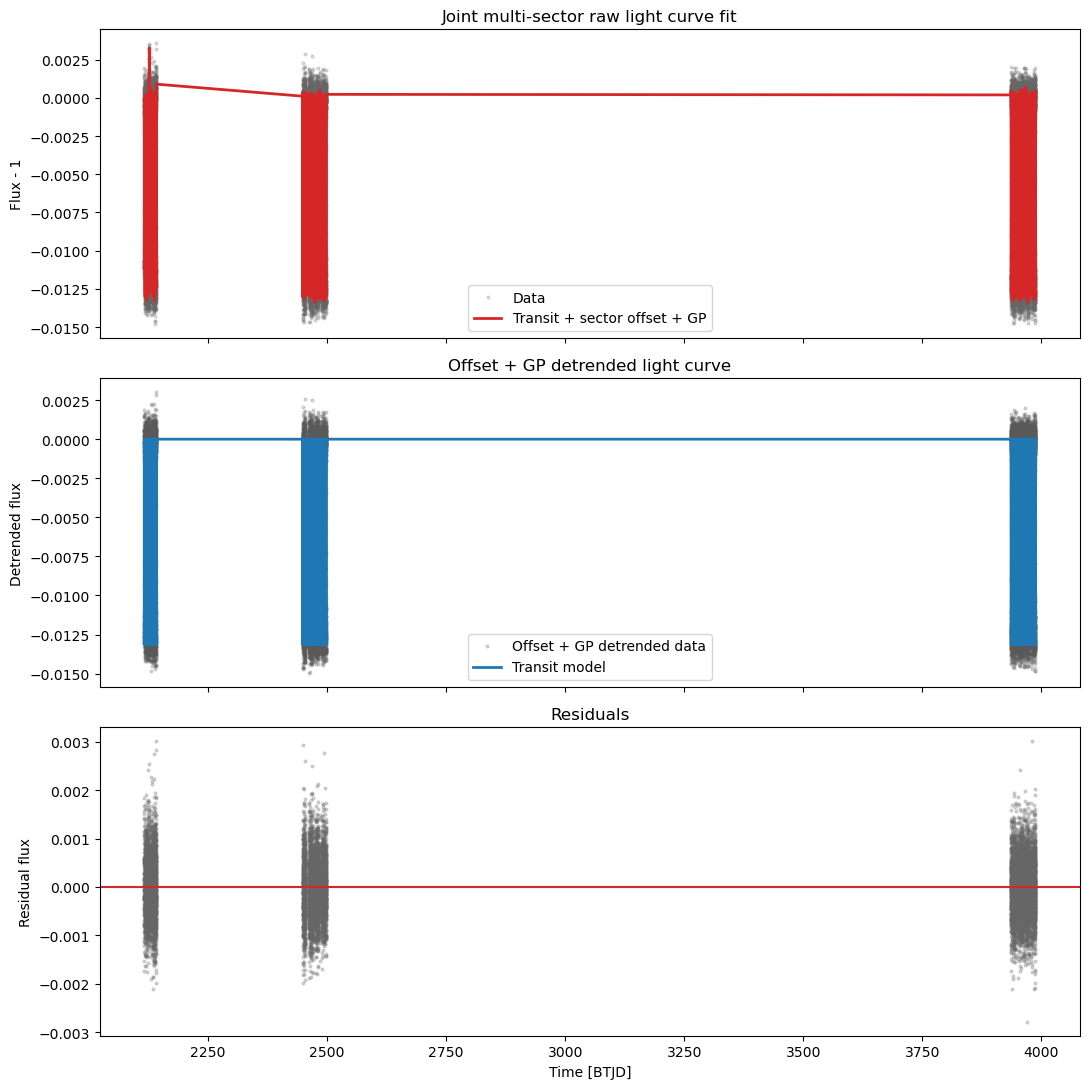

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(11, 11), sharex=True)

axes[0].plot(dataset["time"], dataset["flux"], ".", color="0.4", alpha=0.22, ms=4, label="Data")
axes[0].plot(dataset["time"], best_fit["mean_model"], color="tab:red", lw=2, label="Transit + sector offset + GP")
axes[0].set_title("Joint multi-sector raw light curve fit")
axes[0].set_ylabel("Flux - 1")
axes[0].legend()

axes[1].plot(dataset["time"], best_fit["detrended_flux"], ".", color="0.35", alpha=0.22, ms=4, label="Offset + GP detrended data")
axes[1].plot(dataset["time"], best_fit["transit_model"], color="tab:blue", lw=2, label="Transit model")
axes[1].set_title("Offset + GP detrended light curve")
axes[1].set_ylabel("Detrended flux")
axes[1].legend()

axes[2].plot(dataset["time"], best_fit["residual_flux"], ".", color="0.4", alpha=0.25, ms=4)
axes[2].axhline(0.0, color="tab:red", lw=1.5)
axes[2].set_title("Residuals")
axes[2].set_xlabel("Time [BTJD]")
axes[2].set_ylabel("Residual flux")

plt.tight_layout()

print("Best-fit sector systematics:")
for label, offset, jitter, gp_sigma, gp_rho in zip(
    dataset["sector_labels"],
    best_fit["mean_flux"],
    best_fit["jitter"],
    best_fit["gp_sigma"],
    best_fit["gp_rho"],
):
    print(
        f"  {label}: offset={offset:+.6e}, jitter={jitter:.6e}, "
        f"gp_sigma={gp_sigma:.6e}, gp_rho={gp_rho:.5f} d"
    )
        


Rp/R* = 0.10745 +0.00040 -0.00047
b = 0.0633 +0.0505 -0.0245
rho_star / rho_sun = 0.2866 +0.0020 -0.0044
a/R* = 4.1204 +0.0096 -0.0214
Inclination [deg] = 89.120 +0.342 -0.711
Duration [d] = 0.15651 +0.00033 -0.00026
q1 = 0.2488 +0.0112 -0.0078
q2 = 0.2243 +0.0081 -0.0072
u1 = 0.2246 +0.0078 -0.0071
u2 = 0.2766 +0.0105 -0.0129
Transit depth (%) = 1.1546 +0.0085 -0.0101
Bounds are posterior 16th/50th/84th percentiles from emcee samples.
Acceptance fraction = 0.327
Sectors fit:
  TESS: 2701 cadences
  TESS: 2124 cadences
  TESS: 2505 cadences
  TESS: 4798 cadences


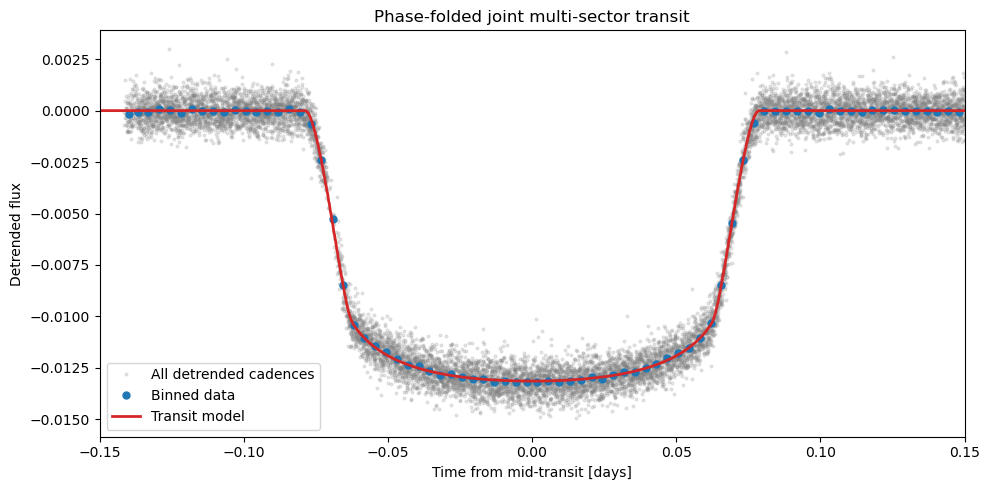

In [10]:
phase_days = best_fit["phase_days"]

bin_edges = np.linspace(-PLOT_WINDOW_D, PLOT_WINDOW_D, 81)
bin_index = np.digitize(phase_days, bin_edges)
binned_phase = []
binned_flux = []
for idx in range(1, len(bin_edges)):
    mask = bin_index == idx
    if np.count_nonzero(mask) < 3:
        continue
    binned_phase.append(np.mean(phase_days[mask]))
    binned_flux.append(np.mean(best_fit["detrended_flux"][mask]))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(phase_days, best_fit["detrended_flux"], ".", color="0.5", alpha=0.18, ms=4, label="All detrended cadences")
ax.plot(np.asarray(binned_phase), np.asarray(binned_flux), "o", color="tab:blue", ms=5, label="Binned data")
ax.plot(best_fit["phase_grid"], best_fit["phase_model_grid"], color="tab:red", lw=2, label="Transit model")
ax.set_xlim(-PLOT_WINDOW_D, PLOT_WINDOW_D)
ax.set_title("Phase-folded joint multi-sector transit")
ax.set_xlabel("Time from mid-transit [days]")
ax.set_ylabel("Detrended flux")
ax.legend()
plt.tight_layout()

summary_stats = best_fit.get("summary_stats")
if summary_stats is not None and "u1" not in summary_stats and "posterior_theta" in best_fit:
    ld_keys = {"q1": [], "q2": [], "u1": [], "u2": []}
    for theta in np.asarray(best_fit["posterior_theta"], dtype=np.float64):
        pars = unpack_params(theta, dataset["n_sectors"])
        ld_keys["q1"].append(pars["q1"])
        ld_keys["q2"].append(pars["q2"])
        ld_keys["u1"].append(pars["u"][0])
        ld_keys["u2"].append(pars["u"][1])
    for key, values in ld_keys.items():
        summary_stats[key] = summarize_interval(values)
    best_fit["summary_stats"] = summary_stats


def print_interval(label, value, fmt, stats=None):
    if stats is None:
        print(f"{label} = {format(value, fmt)}")
        return
    plus = stats.get("plus", stats["upper"] - stats["median"])
    minus = stats.get("minus", stats["median"] - stats["lower"])
    print(
        f"{label} = {format(stats['median'], fmt)} "
        f"+{format(plus, fmt)} -{format(minus, fmt)}"
    )

print_interval("Rp/R*", best_fit["r"], ".5f", None if summary_stats is None else summary_stats["r"])
print_interval("b", best_fit["b"], ".4f", None if summary_stats is None else summary_stats["b"])
print_interval("rho_star / rho_sun", best_fit["rho_star_solar"], ".4f", None if summary_stats is None else summary_stats["rho_star_solar"])
print_interval("a/R*", best_fit["a_over_rstar"], ".4f", None if summary_stats is None else summary_stats["a_over_rstar"])
print_interval("Inclination [deg]", best_fit["inclination_deg"], ".3f", None if summary_stats is None else summary_stats["inclination_deg"])
print_interval("Duration [d]", best_fit["duration"], ".5f", None if summary_stats is None else summary_stats["duration"])
print_interval("q1", best_fit["q1"], ".4f", None if summary_stats is None else summary_stats.get("q1"))
print_interval("q2", best_fit["q2"], ".4f", None if summary_stats is None else summary_stats.get("q2"))
print_interval("u1", best_fit["u"][0], ".4f", None if summary_stats is None else summary_stats.get("u1"))
print_interval("u2", best_fit["u"][1], ".4f", None if summary_stats is None else summary_stats.get("u2"))
print_interval("Transit depth (%)", 100.0 * best_fit["r"] ** 2, ".4f", None if summary_stats is None else summary_stats["transit_depth_percent"])
if summary_stats is not None:
    print("Bounds are posterior 16th/50th/84th percentiles from emcee samples.")
    print(f"Acceptance fraction = {best_fit['emcee_acceptance_fraction']:.3f}")
print("Sectors fit:")
for label, count in zip(dataset["sector_labels"], dataset["sector_counts"]):
    print(f"  {label}: {int(count)} cadences")
        


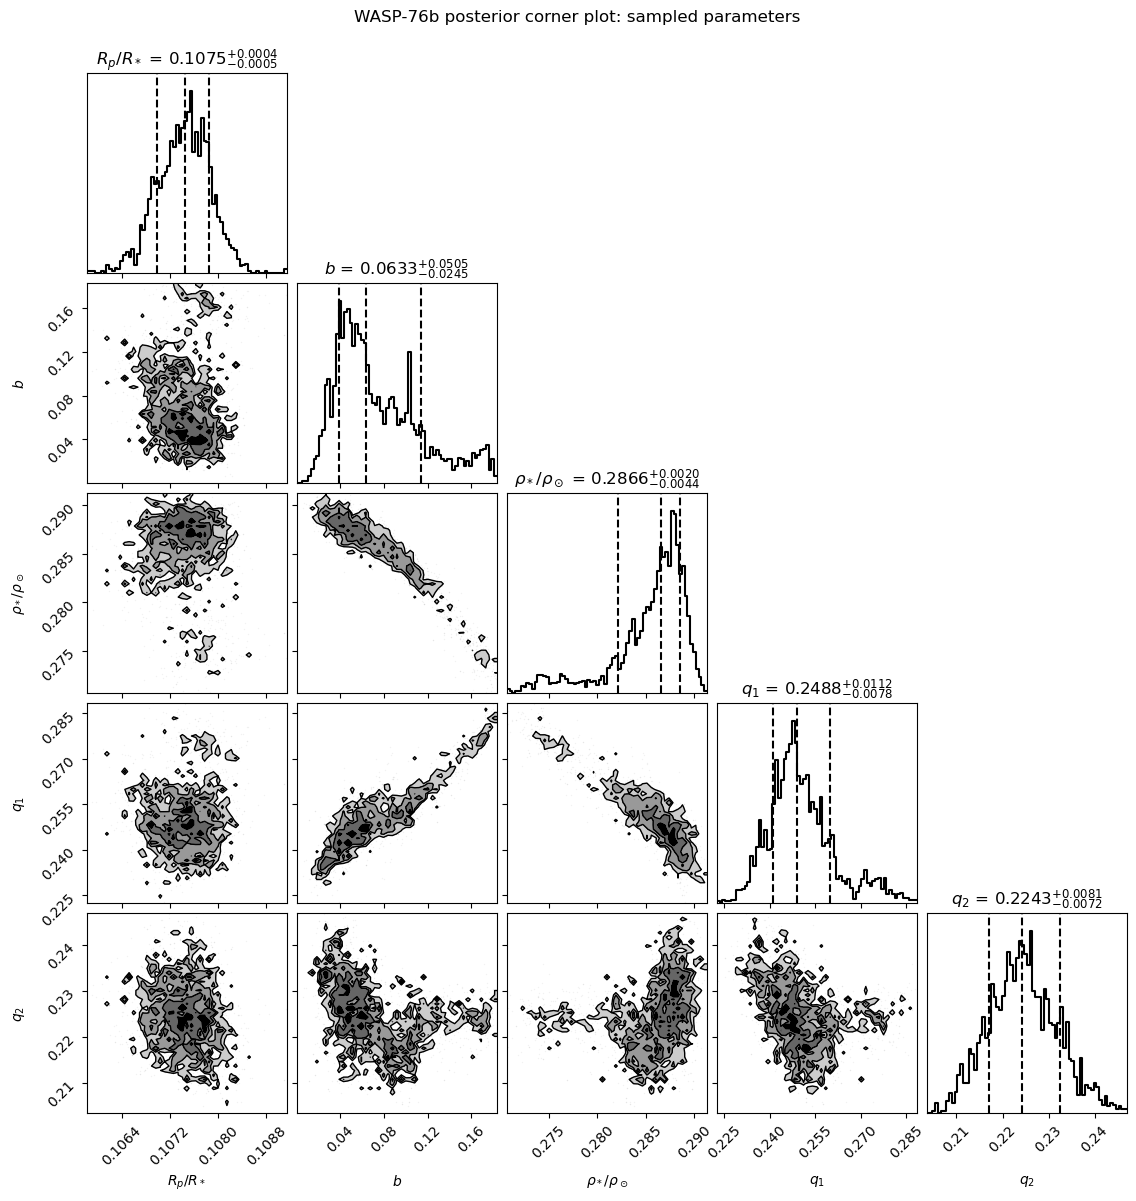

In [11]:
try:
    import corner
except ImportError as exc:
    raise ImportError(
        "corner is not installed in this environment. Update exometal from environment-exometal.yml or install the `corner` package."
    ) from exc

theta_samples = np.asarray(best_fit.get("posterior_theta"), dtype=np.float64)
if theta_samples.size == 0:
    raise RuntimeError("No posterior samples are available for the corner plot.")

max_corner_samples = 15000
if theta_samples.shape[0] > max_corner_samples:
    rng = np.random.default_rng(123)
    theta_samples = theta_samples[rng.choice(theta_samples.shape[0], max_corner_samples, replace=False)]

SHOW_DERIVED_CORNER = False

corner_columns = {
    "r": [],
    "b": [],
    "rho_star_solar": [],
    "q1": [],
    "q2": [],
}
derived_corner_columns = {
    "r": [],
    "b": [],
    "rho_star_solar": [],
    "a_over_rstar": [],
    "u1": [],
    "u2": [],
}

for theta in theta_samples:
    pars = unpack_params(theta, dataset["n_sectors"])
    corner_columns["r"].append(pars["r"])
    corner_columns["b"].append(pars["b"])
    corner_columns["rho_star_solar"].append(pars["rho_star_solar"])
    corner_columns["q1"].append(pars["q1"])
    corner_columns["q2"].append(pars["q2"])
    derived_corner_columns["r"].append(pars["r"])
    derived_corner_columns["b"].append(pars["b"])
    derived_corner_columns["rho_star_solar"].append(pars["rho_star_solar"])
    derived_corner_columns["a_over_rstar"].append(pars["a_over_rstar"])
    derived_corner_columns["u1"].append(pars["u"][0])
    derived_corner_columns["u2"].append(pars["u"][1])

corner_keys = ["r", "b", "rho_star_solar", "q1", "q2"]
corner_labels = [r"$R_p/R_*$", r"$b$", r"$\rho_*/\rho_\odot$", r"$q_1$", r"$q_2$"]
corner_data = np.column_stack([np.asarray(corner_columns[key], dtype=np.float64) for key in corner_keys])

derived_corner_keys = ["r", "b", "rho_star_solar", "a_over_rstar", "u1", "u2"]
derived_corner_labels = [r"$R_p/R_*$", r"$b$", r"$\rho_*/\rho_\odot$", r"$a/R_*$", r"$u_1$", r"$u_2$"]
derived_corner_data = np.column_stack([np.asarray(derived_corner_columns[key], dtype=np.float64) for key in derived_corner_keys])

corner_bins = 45
corner_hist_bin_factor = 1.6
corner_smooth = 0.35
corner_smooth_1d = 0.2
corner_levels = (
    1.0 - np.exp(-0.125),
    1.0 - np.exp(-0.5),
    1.0 - np.exp(-1.125),
    1.0 - np.exp(-2.0),
)

def make_corner_plot(data, labels, title):
    fig = corner.corner(
        data,
        labels=labels,
        quantiles=[0.16, 0.5, 0.84],
        show_titles=True,
        title_fmt=".4f",
        bins=corner_bins,
        hist_bin_factor=corner_hist_bin_factor,
        smooth=corner_smooth,
        smooth1d=corner_smooth_1d,
        plot_datapoints=True,
        fill_contours=True,
        levels=corner_levels,
        data_kwargs={"alpha": 0.06, "ms": 1.0, "color": "0.15"},
        contour_kwargs={"linewidths": 1.0, "colors": "k"},
    )
    fig.suptitle(title, y=1.02)
    plt.show()

make_corner_plot(
    corner_data,
    corner_labels,
    "WASP-76b posterior corner plot: sampled parameters",
)

if SHOW_DERIVED_CORNER:
    make_corner_plot(
        derived_corner_data,
        derived_corner_labels,
        "WASP-76b posterior corner plot: derived parameters",
    )
